In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

netflix = pd.read_csv("netflix.csv")

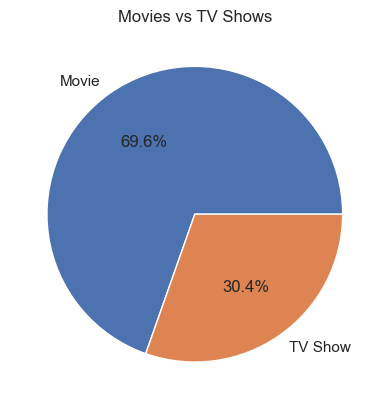

In [2]:
## Q1. What is the ratio of Movies vs TV Shows on Netflix?
type_counts = netflix['type'].value_counts()

type_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.ylabel("")
plt.show()

In [ ]:
# Insight:
# Movies dominate Netflix content.
# TV Shows are fewer but growing in importance.

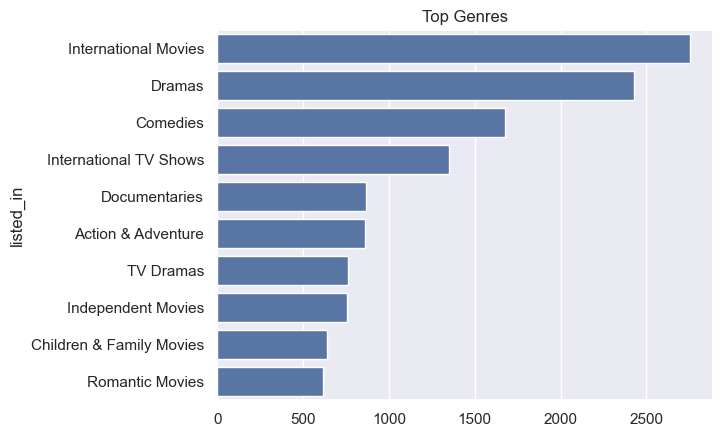

In [3]:
# 2.Most Popular Genres on Netflix
genres = netflix['listed_in'].dropna().str.split(', ')
all_genres = genres.explode()

genre_count = all_genres.value_counts().head(10)

sns.barplot(x=genre_count.values, y=genre_count.index)
plt.title("Top Genres")
plt.show()

In [ ]:
# Insight:
# Drama and International content are most popular.
# Netflix focuses heavily on diverse global storytelling.

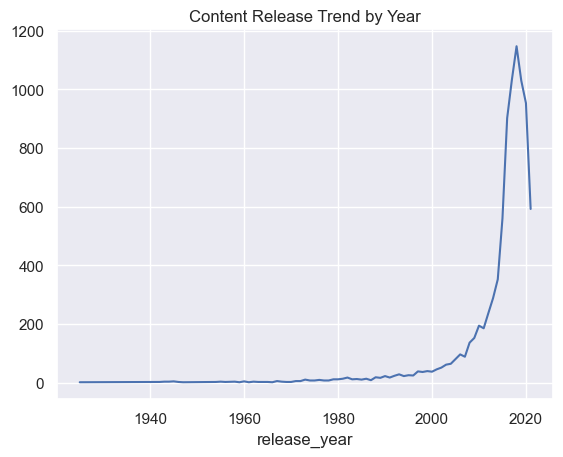

In [4]:
# 3. Content Release Trend by Year
y = netflix['release_year'].value_counts().sort_index()

sns.lineplot(x=y.index, y=y.values)
plt.title("Content Release Trend by Year")
plt.show()

In [ ]:
# Insight:
# Recent years have more content.
# Indicates rapid growth in production.

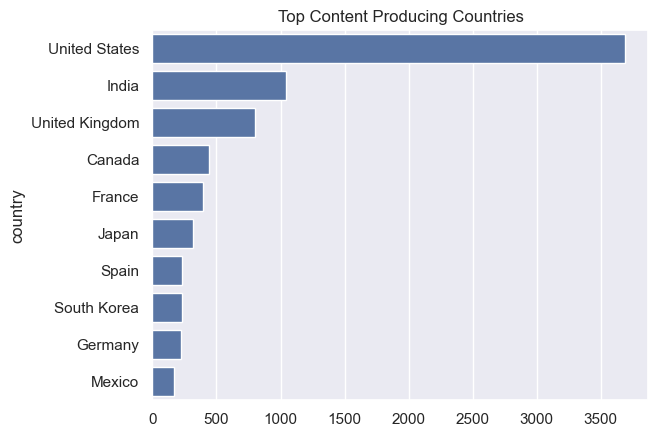

In [5]:
# 4. Top Content Producing Countries
c = netflix['country'].dropna().str.split(', ').explode().value_counts().head(10)

sns.barplot(x=c.values, y=c.index)
plt.title("Top Content Producing Countries")
plt.show()

In [ ]:
# Insight:
# USA leads content production.
# India and UK are also major contributors.

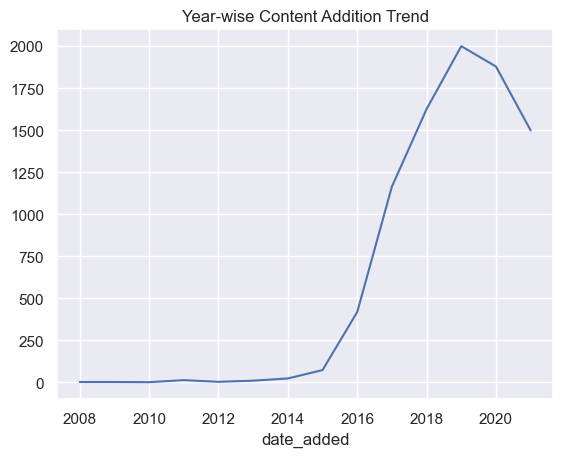

In [6]:
# 5. Year-wise Content Addition Trend
netflix['date_added'] = pd.to_datetime(netflix['date_added'], errors='coerce')
y = netflix['date_added'].dt.year.value_counts().sort_index()

sns.lineplot(x=y.index, y=y.values)
plt.title("Year-wise Content Addition Trend")
plt.show()

In [ ]:
# Insight:
# Content addition increased sharply after 2015.
# Netflix expanded aggressively during this period.

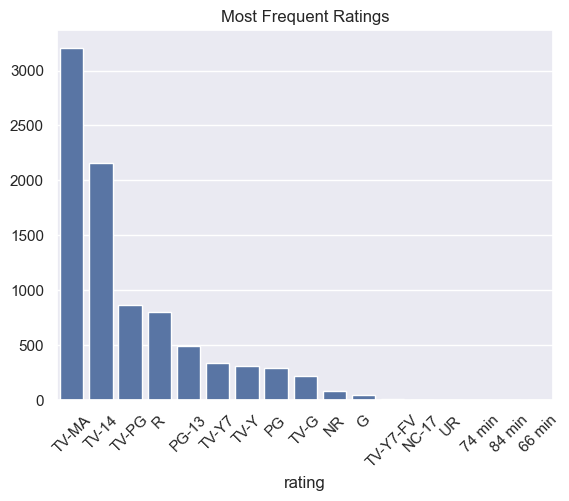

In [7]:
# 6. Most Frequent Ratings
r = netflix['rating'].value_counts()

sns.barplot(x=r.index, y=r.values)
plt.title("Most Frequent Ratings")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Insight:
# TV-MA is the most common rating.
# Netflix targets mature audiences heavily.

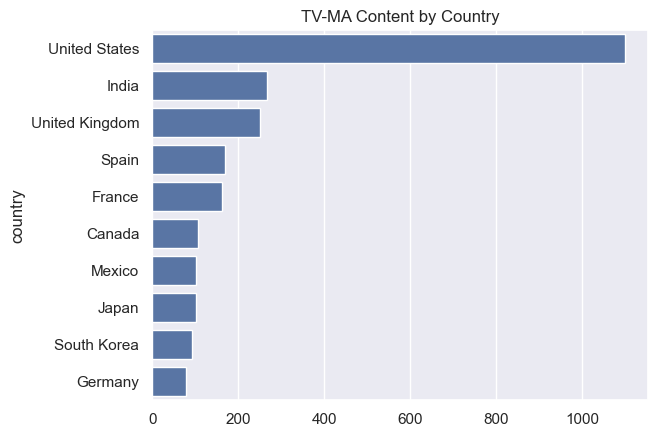

In [8]:
# 7. TV-MA Content by Country
c = netflix[netflix['rating'] == 'TV-MA']['country'].dropna().str.split(', ').explode().value_counts().head(10)

sns.barplot(x=c.values, y=c.index)
plt.title("TV-MA Content by Country")
plt.show()

In [ ]:
# Insight:
# USA produces most mature content.
# Western markets prefer adult content more.

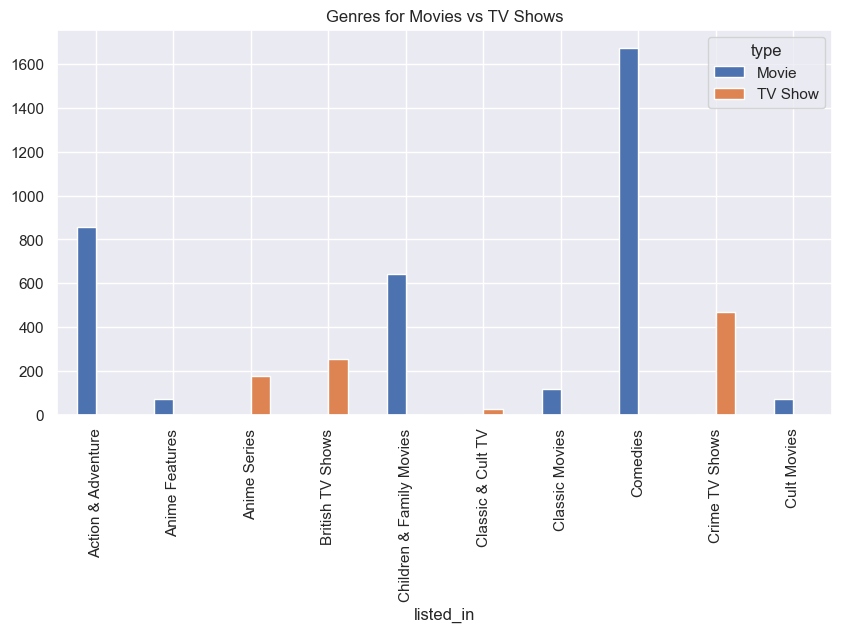

In [9]:
# 8. Genres for Movies vs TV Shows
d = netflix.assign(listed_in=netflix['listed_in'].str.split(', ')).explode('listed_in')
g = d.groupby(['listed_in', 'type']).size().unstack().fillna(0).head(10)

g.plot(kind='bar', figsize=(10,5))
plt.title("Genres for Movies vs TV Shows")
plt.show()

In [ ]:
# Insight:
# Movies dominate drama & international genres.
# TV shows focus more on series-based storytelling.

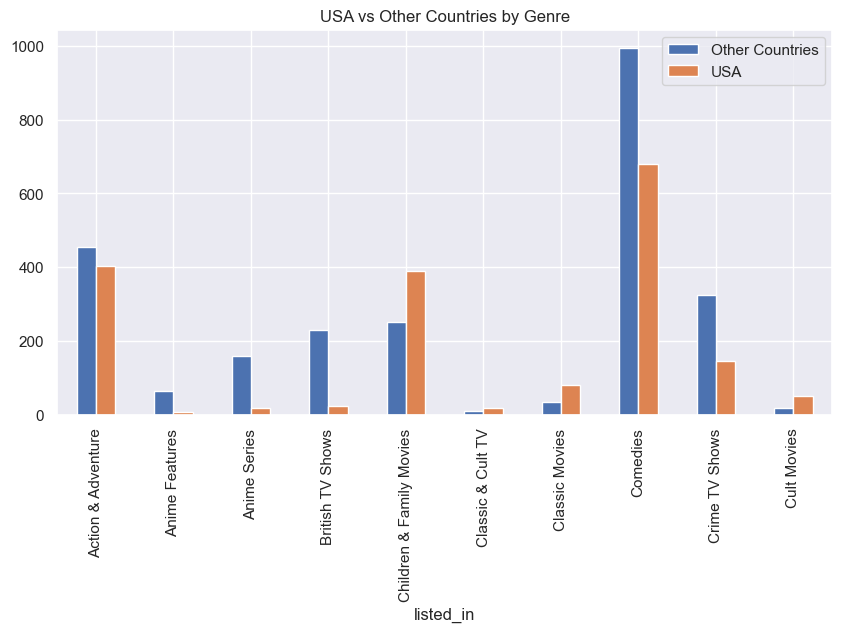

In [10]:
# 9. USA vs Other Countries by Genre
d = netflix.assign(is_USA=netflix['country'].str.contains('United States', na=False),
                   listed_in=netflix['listed_in'].str.split(', ')).explode('listed_in')
g = d.groupby(['listed_in', 'is_USA']).size().unstack().fillna(0).head(10)
g.columns = ['Other Countries', 'USA']

g.plot(kind='bar', figsize=(10,5))
plt.title("USA vs Other Countries by Genre")
plt.show()

In [ ]:
# Insight:
# US focuses more on mainstream genres.
# Other countries show more diverse content.

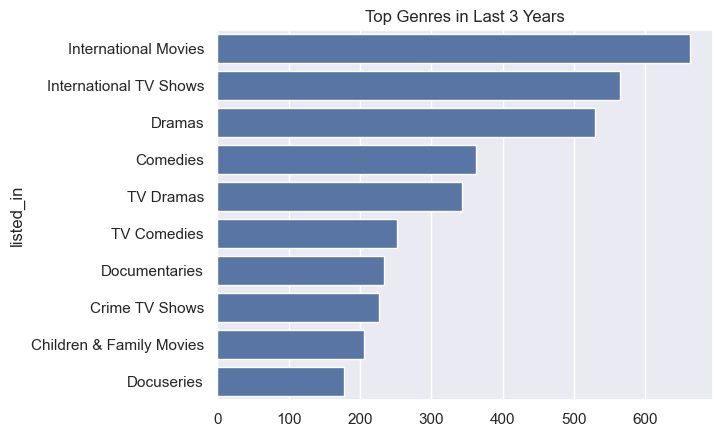

In [11]:
# 10. Top Genres in Last 3 Years
g = netflix[netflix['release_year'] >= netflix['release_year'].max()-2]['listed_in'].str.split(', ').explode().value_counts().head(10)

sns.barplot(x=g.values, y=g.index)
plt.title("Top Genres in Last 3 Years")
plt.show()


In [ ]:
# Insight:
# Recent content still dominated by drama.
# Global genres are increasing rapidly.

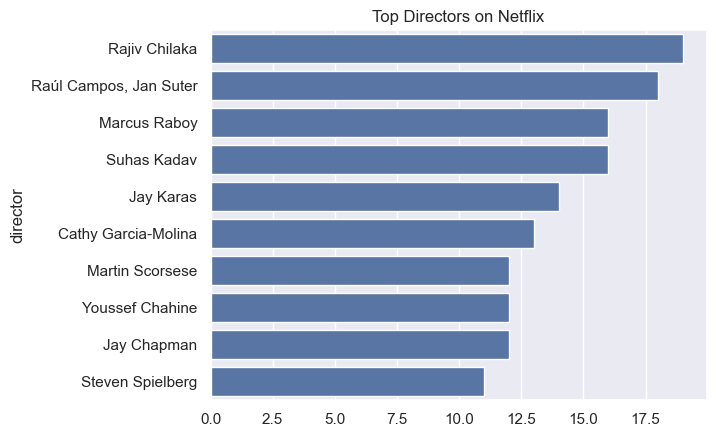

In [12]:
# 11. Top Directors on Netflix
d = netflix['director'].dropna().value_counts().head(10)

sns.barplot(x=d.values, y=d.index)
plt.title("Top Directors on Netflix")
plt.show()


In [ ]:
# Insight:
# Few directors contribute multiple titles.
# Partnership with top directors is important.

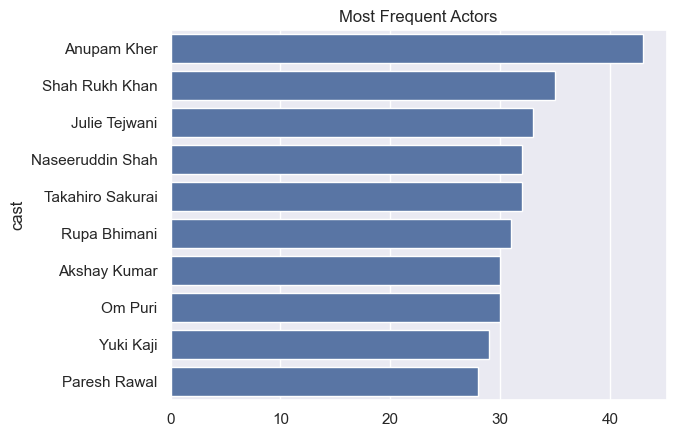

In [13]:
# 12. Most Frequent Actors
a = netflix['cast'].dropna().str.split(', ').explode().value_counts().head(10)

sns.barplot(x=a.values, y=a.index)
plt.title("Most Frequent Actors")
plt.show()


In [ ]:
# Insight:
# Popular actors appear repeatedly.
# Star power plays a role in engagement.

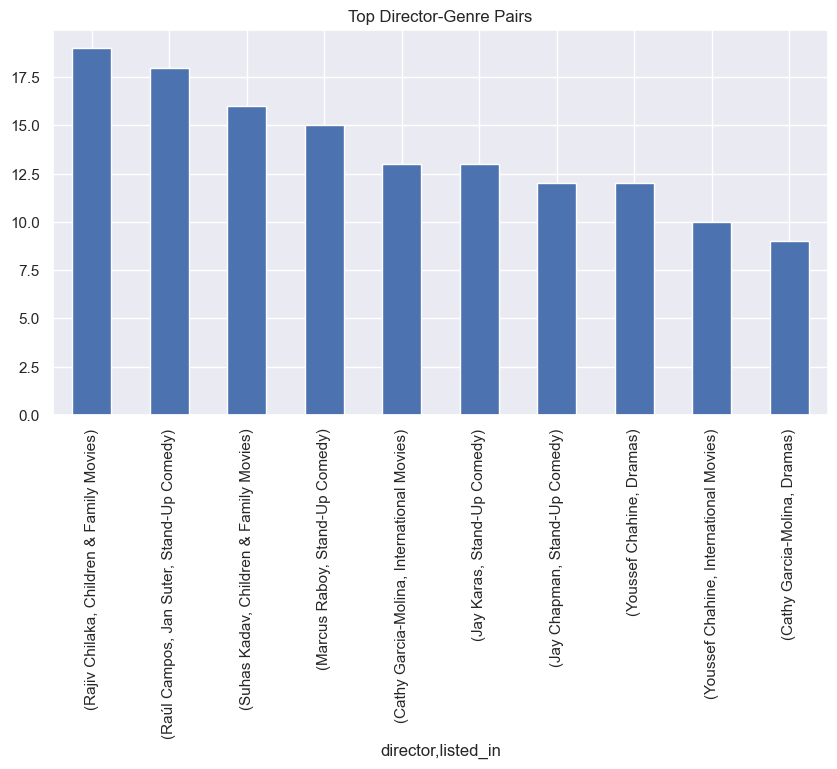

In [14]:
# 13. Top Director-Genre Pairs
p = netflix[['director', 'listed_in']].dropna().assign(listed_in=netflix['listed_in'].str.split(', ')).explode('listed_in')
p = p.groupby(['director', 'listed_in']).size().sort_values(ascending=False).head(10)

p.plot(kind='bar', figsize=(10,5))
plt.title("Top Director-Genre Pairs")
plt.show()

In [ ]:
# Insight:
# Certain directors specialize in specific genres.
# Genre expertise improves consistency.

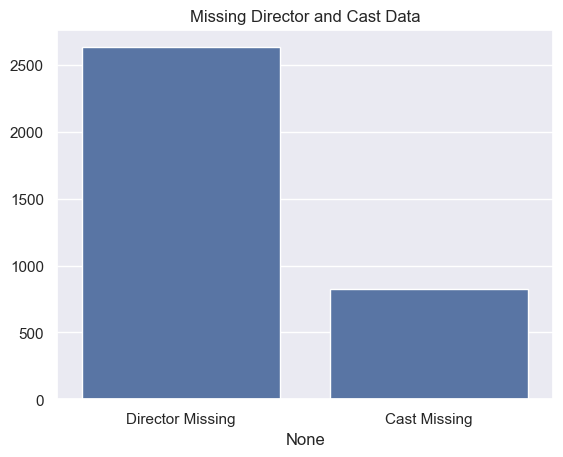

In [15]:
# 14. Missing Director and Cast Data
m = pd.Series([netflix['director'].isna().sum(), netflix['cast'].isna().sum()],
              index=['Director Missing', 'Cast Missing'])

sns.barplot(x=m.index, y=m.values)
plt.title("Missing Director and Cast Data")
plt.show()

In [ ]:
# Insight:
# Some data is missing for director/cast.
# Data quality needs improvement.

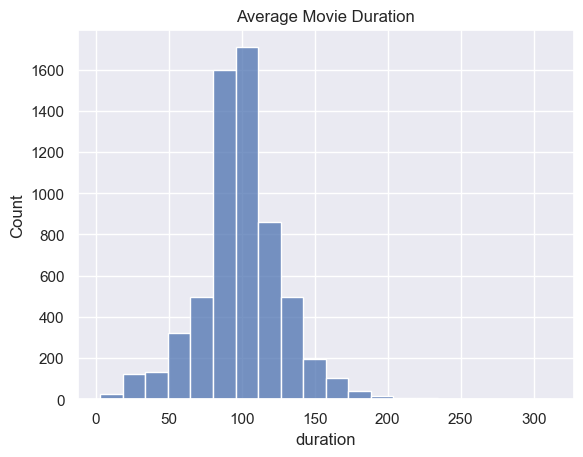

In [16]:
# 15. Average Movie Duration
m = netflix[netflix['type'] == 'Movie']['duration'].str.replace(' min', '', regex=False).astype(float)

sns.histplot(m, bins=20)
plt.title("Average Movie Duration")
plt.show()

In [ ]:
# Insight:
# Most movies are around 90–120 minutes.
# Standard movie length dominates.

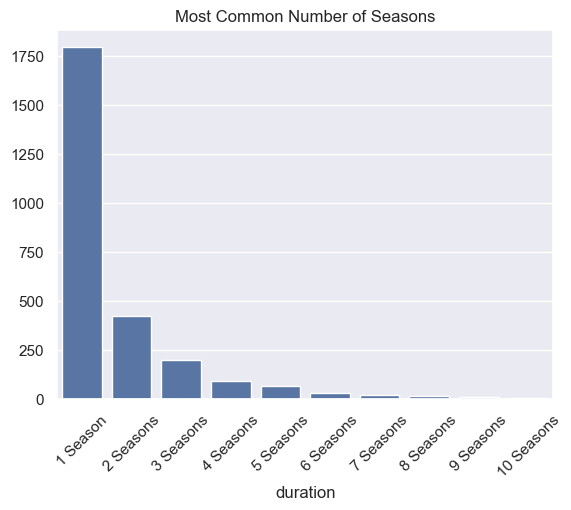

In [17]:
# 16. Most Common Number of Seasons
s = netflix[netflix['type'] == 'TV Show']['duration'].value_counts().head(10)

sns.barplot(x=s.index, y=s.values)
plt.title("Most Common Number of Seasons")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Insight:
# Most shows have 1–2 seasons.
# Short series are common on Netflix.

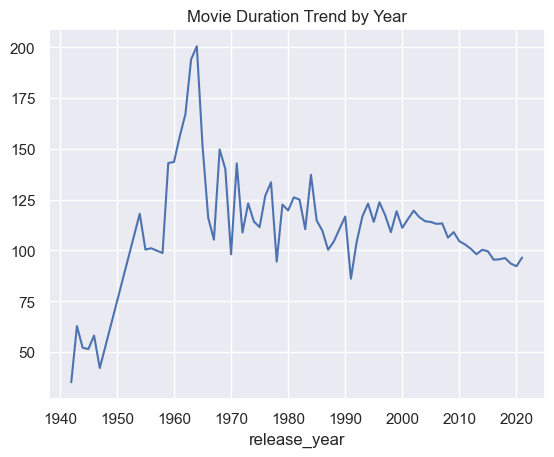

In [18]:
# 17. Movie Duration Trend by Year
m = netflix[netflix['type'] == 'Movie'].copy()
m['duration'] = m['duration'].str.replace(' min', '', regex=False).astype(float)
y = m.groupby('release_year')['duration'].mean()

sns.lineplot(x=y.index, y=y.values)
plt.title("Movie Duration Trend by Year")
plt.show()

In [ ]:
# Insight:
# Movie duration remains fairly stable.
# No major change in viewer attention span.

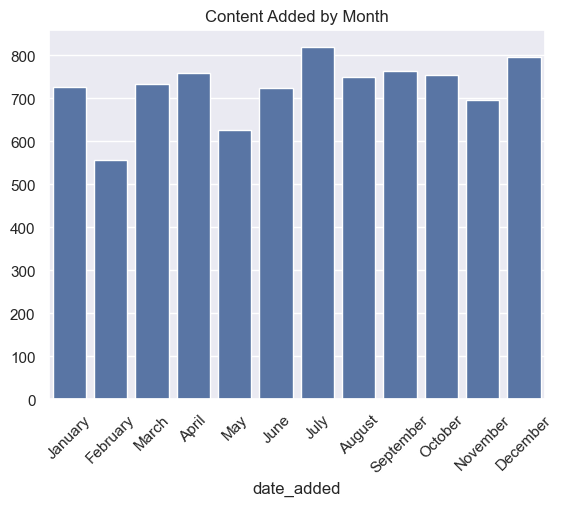

In [19]:
# 18. Content Added by Month
netflix['date_added'] = pd.to_datetime(netflix['date_added'], errors='coerce')
m = netflix['date_added'].dt.month_name().value_counts().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

sns.barplot(x=m.index, y=m.values)
plt.title("Content Added by Month")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Insight:
# Certain months have more releases.
# Netflix follows seasonal release strategy.

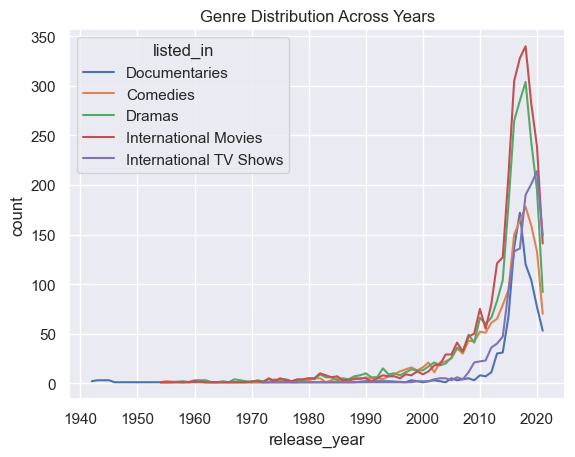

In [20]:
# 19. Genre Distribution Across Years
d = netflix.assign(listed_in=netflix['listed_in'].str.split(', ')).explode('listed_in')
g = d[d['listed_in'].isin(d['listed_in'].value_counts().head(5).index)]
g = g.groupby(['release_year', 'listed_in']).size().reset_index(name='count')

sns.lineplot(data=g, x='release_year', y='count', hue='listed_in')
plt.title("Genre Distribution Across Years")
plt.show()

In [ ]:
# Insight:
# Genres evolve over time.
# Drama remains consistently dominant.

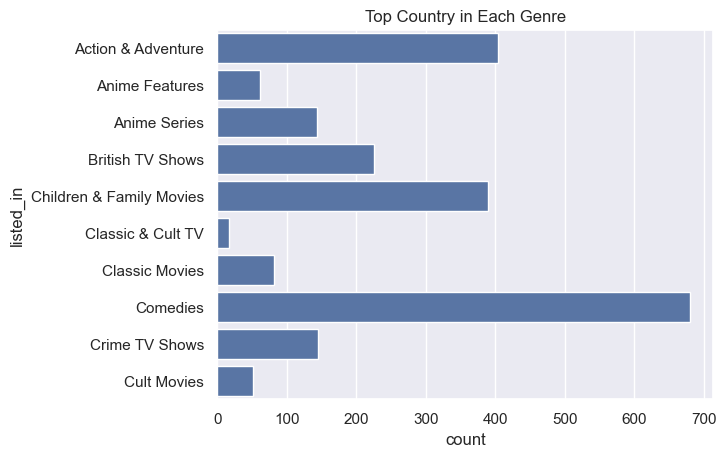

In [21]:
# 20. Top Country in Each Genre
d = netflix[['country', 'listed_in']].dropna()
d = d.assign(country=d['country'].str.split(', '), listed_in=d['listed_in'].str.split(', ')).explode('country').explode('listed_in')
g = d.groupby(['listed_in', 'country']).size().reset_index(name='count')
g = g.sort_values(['listed_in', 'count'], ascending=[True, False]).groupby('listed_in').head(1)

sns.barplot(data=g.head(10), x='count', y='listed_in')
plt.title("Top Country in Each Genre")
plt.show()

In [ ]:
# Insight:
# Different countries dominate different genres.
# Helps in regional content strategy.